# Dam on a river network

Pick a dam, resolve its HydroSHEDS `main_riv`, draw reaches and co-located dams, and summarize HydroATLAS / FFR fields. Build the database first (`clean_data.py`, then `ingest.py` from the repo root). This notebook assumes the working directory is the repository root (or one level up from `notebooks/`).

River lines omit the shortest reaches (`shape_length` filter) so the map stays responsive.

In [2]:
from pathlib import Path

import duckdb
import geopandas as gpd
import ibis
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "database" / "superbadd.duckdb").is_file():
    ROOT = ROOT.parent

DB = ROOT / "database" / "superbadd.duckdb"
TARGET_DAM = "Keban"

con = duckdb.connect(str(DB))
con.execute("LOAD spatial;")

In [3]:
main_riv = con.execute(
    """
    SELECT ra.main_riv
    FROM gdw AS g
    JOIN riveratlas AS ra ON g.hyriv_id = ra.hyriv_id
    WHERE g.dam_name = ?
    LIMIT 1
    """,
    [TARGET_DAM],
).fetchone()
if main_riv is None:
    raise ValueError(f"No dam named {TARGET_DAM!r} with a RiverATLAS reach.")
main_riv = main_riv[0]

In [4]:
params = [main_riv]

basin_stats = con.execute(
    """
    WITH r AS (SELECT DISTINCT hybas_l12 AS hid FROM riveratlas WHERE main_riv = ?)
    SELECT COUNT(*) AS n_basins,
           AVG(b.sub_area) AS mean_sub_area,
           AVG(b.up_area) AS mean_up_area
    FROM basinatlas AS b
    WHERE b.hybas_id IN (SELECT hid FROM r)
    """,
    params,
).df()

reach_stats = con.execute(
    """
    SELECT COUNT(*) AS n_reaches, AVG(ord_flow) AS mean_ord_flow
    FROM riveratlas WHERE main_riv = ?
    """,
    params,
).df()

ffr_stats = con.execute(
    """
    SELECT AVG(f.csi) AS mean_csi,
           AVG(f.dis_av_cms) AS mean_dis_m3_s,
           AVG(f.riv_ord) AS mean_riv_ord,
           COUNT(*) AS n_ffr_rows
    FROM ffr AS f
    WHERE f.hyriv_id IN (SELECT DISTINCT hyriv_id FROM riveratlas WHERE main_riv = ?)
    """,
    params,
).df()

dams_on_net = con.execute(
    """
    SELECT g.dam_name, g.country, g.cap_mcm, g.dis_avg_ls
    FROM gdw AS g
    JOIN riveratlas AS ra ON g.hyriv_id = ra.hyriv_id
    WHERE ra.main_riv = ? AND g.dam_name IS NOT NULL
    ORDER BY g.cap_mcm DESC NULLS LAST
    """,
    params,
).df()

display(basin_stats)
display(reach_stats)
display(ffr_stats)
display(dams_on_net.head(15))

,n_basins,mean_sub_area,mean_up_area
0,6346,130.568311,13755.065254


,n_reaches,mean_ord_flow
0,40311,7.343529


,mean_csi,mean_dis_m3_s,mean_riv_ord,n_ffr_rows
0,96.687875,29.219695,7.343529,40311


,dam_name,country,cap_mcm,dis_avg_ls
0,Ataturk,Turkey,48700.0,701683.0
1,Thartar,Iraq,43500.0,43226.0
2,Keban,Turkey,30700.0,594586.0
3,Raza Dike,Iraq,26000.0,0.0
4,Mosul,Iraq,12500.0,776235.0
5,Tabqa,Syria,11600.0,733186.0
6,Haditha,Iraq,11000.0,823593.0
7,Ilisu,Turkey,10410.0,574053.0
8,Karakaya,Turkey,9580.0,672268.0
9,Karkheh,Iran,7300.0,296563.0


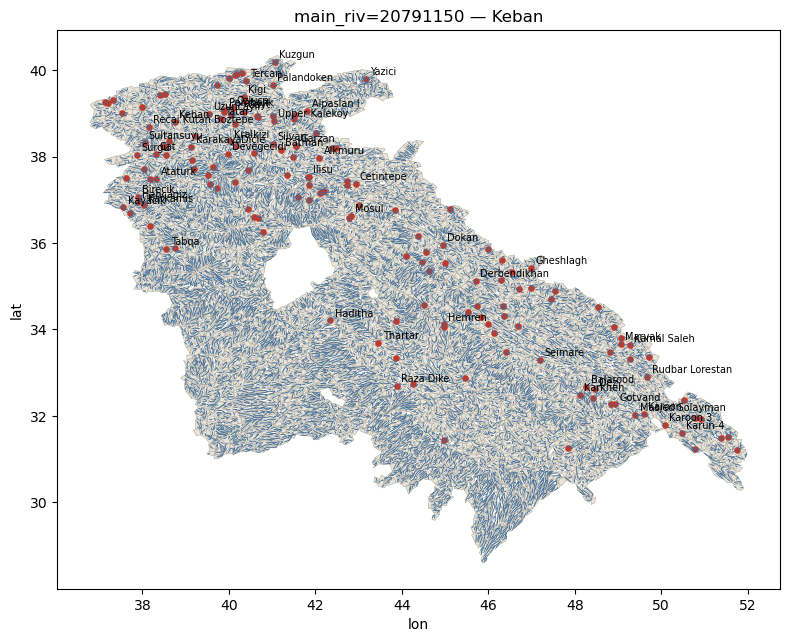

In [5]:
tol = 0.02
min_len = 0.06
rivers = con.execute(
    "SELECT ST_AsText(ST_Simplify(geometry, ?)) AS wkt FROM riveratlas WHERE main_riv = ? AND shape_length > ?",
    [tol, main_riv, min_len],
).df()
dams = con.execute(
    """
    SELECT g.dam_name, ST_AsText(g.geometry) AS wkt
    FROM gdw AS g
    JOIN riveratlas AS ra ON g.hyriv_id = ra.hyriv_id
    WHERE ra.main_riv = ? AND g.dam_name IS NOT NULL
    """,
    params,
).df()
basins = con.execute(
    """
    SELECT ST_AsText(ST_Simplify(b.geometry, ?)) AS wkt
    FROM basinatlas AS b
    WHERE b.hybas_id IN (SELECT DISTINCT hybas_l12 FROM riveratlas WHERE main_riv = ?)
    """,
    [tol * 2, main_riv],
).df()

g_riv = gpd.GeoDataFrame(rivers, geometry=gpd.GeoSeries.from_wkt(rivers["wkt"], crs="EPSG:4326"), crs="EPSG:4326")
g_dam = gpd.GeoDataFrame(dams, geometry=gpd.GeoSeries.from_wkt(dams["wkt"], crs="EPSG:4326"), crs="EPSG:4326")
g_bas = gpd.GeoDataFrame(basins, geometry=gpd.GeoSeries.from_wkt(basins["wkt"], crs="EPSG:4326"), crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(8, 8))
g_bas.plot(ax=ax, color="#e8e4da", edgecolor="#9c9688", linewidth=0.3)
g_riv.plot(ax=ax, color="#3d6b99", linewidth=0.6)
g_dam.plot(ax=ax, color="#c0392b", markersize=14)
for _, r in g_dam.iterrows():
    ax.annotate(r["dam_name"], xy=(r.geometry.x, r.geometry.y), xytext=(3, 3), textcoords="offset points", fontsize=7)
ax.set_title(f"main_riv={main_riv} — {TARGET_DAM}")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_aspect("equal")
plt.tight_layout()

In [6]:
ib = ibis.connect(f"duckdb:///{DB.as_posix()}")
g, f = ib.table("gdw"), ib.table("ffr")
expr = (
    g.join(f, g.hyriv_id == f.hyriv_id)
    .filter(g.country == "Turkey")
    .select(g.dam_name, g.dis_avg_ls, f.csi)
    .limit(12)
)
sql = ibis.to_sql(expr, dialect="duckdb")
print(sql)
display(con.execute(sql).df())
ib.disconnect()

SELECT
  "t4"."dam_name",
  "t4"."dis_avg_ls",
  "t4"."csi"
FROM (
  SELECT
    "t2"."gdw_id",
    "t2"."res_name",
    "t2"."dam_name",
    "t2"."alt_name",
    "t2"."dam_type",
    "t2"."lake_ctrl",
    "t2"."river",
    "t2"."alt_river",
    "t2"."main_basin",
    "t2"."sub_basin",
    "t2"."country",
    "t2"."sec_cntry",
    "t2"."admin_unit",
    "t2"."sec_admin",
    "t2"."near_city",
    "t2"."alt_city",
    "t2"."year_dam",
    "t2"."pre_year",
    "t2"."year_src",
    "t2"."alt_year",
    "t2"."rem_year",
    "t2"."timeline",
    "t2"."year_txt",
    "t2"."dam_hgt_m",
    "t2"."alt_hgt_m",
    "t2"."dam_len_m",
    "t2"."alt_len_m",
    "t2"."area_skm",
    "t2"."area_poly",
    "t2"."area_rep",
    "t2"."area_max",
    "t2"."area_min",
    "t2"."cap_mcm",
    "t2"."cap_max",
    "t2"."cap_rep",
    "t2"."cap_min",
    "t2"."dis_avg_ls",
    "t2"."elev_masl",
    "t2"."catch_skm",
    "t2"."catch_rep",
    "t2"."power_mw",
    "t2"."data_info",
    "t2"."use_irri",
    "t2"."

,dam_name,dis_avg_ls,csi
0,,451.0,54.03712
1,,80.0,99.89500
2,,203.0,57.11006
3,Armagan,574.0,23.96584
4,,1671.0,99.76215
5,Kayalikoy,2234.0,23.22187
6,,31.0,99.82000
7,,1386.0,44.67390
8,,584.0,99.57180
9,,968.0,99.68500


In [8]:
con.close()